In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device    : {DEVICE}')

PyTorch version : 1.4.0
CUDA available  : True
Using device    : cuda


In [ ]:
DATA_DIR   = Path('/kaggle/input/chest-xray-pneumonia/chest_xray/test')
MODEL_PATH = Path('/kaggle/input/models/hvththanh/mobilenet/pytorch/default/1/mobilenetv2_best_compat.pth')

IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_CLASSES = 2
CLASS_NAMES = ['NORMAL', 'PNEUMONIA']   # 0 = NORMAL, 1 = PNEUMONIA

# Kiểm tra đường dẫn
assert DATA_DIR.exists(),   f'Không tìm thấy data dir: {DATA_DIR}'
assert MODEL_PATH.exists(), f'Không tìm thấy model: {MODEL_PATH}'

normal_imgs    = list((DATA_DIR / 'NORMAL').glob('*.jpeg')) + \
                 list((DATA_DIR / 'NORMAL').glob('*.jpg'))  + \
                 list((DATA_DIR / 'NORMAL').glob('*.png'))
pneumonia_imgs = list((DATA_DIR / 'PNEUMONIA').glob('*.jpeg')) + \
                 list((DATA_DIR / 'PNEUMONIA').glob('*.jpg'))   + \
                 list((DATA_DIR / 'PNEUMONIA').glob('*.png'))

print(f'NORMAL    : {len(normal_imgs):>4} ảnh')
print(f'PNEUMONIA : {len(pneumonia_imgs):>4} ảnh')
print(f'Tổng      : {len(normal_imgs) + len(pneumonia_imgs):>4} ảnh')

NORMAL    :  234 ảnh
PNEUMONIA :  390 ảnh
Tổng      :  624 ảnh


## Dataset & DataLoader

In [ ]:
class ChestXRayDataset(Dataset):
    """Dataset đọc ảnh từ 2 folder NORMAL / PNEUMONIA."""

    def __init__(self, data_dir, transform=None):
        self.data_dir  = Path(data_dir)
        self.transform = transform
        self.samples   = []   # list of (path, label)

        for label, cls in enumerate(CLASS_NAMES):
            cls_dir = self.data_dir / cls
            for ext in ('*.jpeg', '*.jpg', '*.png'):
                for img_path in cls_dir.glob(ext):
                    self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label, str(img_path)


# Transform giống lúc train (không augment, chỉ resize + normalize)
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

test_dataset = ChestXRayDataset(DATA_DIR, transform=test_transform)
test_loader  = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f'Dataset size : {len(test_dataset)} samples')
print(f'Batches      : {len(test_loader)}')

Dataset size : 624 samples
Batches      : 20


## Load MobileNetV2

In [ ]:
def build_mobilenetv2(num_classes=2, pretrained=False):
    """Xây dựng MobileNetV2 với classifier 2 lớp – khớp với kiến trúc lúc train."""
    model = models.mobilenet_v2(pretrained=pretrained)
    in_features = model.classifier[1].in_features   # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2, inplace=False),
        nn.Linear(in_features, num_classes)
    )
    return model


model = build_mobilenetv2(num_classes=NUM_CLASSES)

# Load weights
checkpoint = torch.load(str(MODEL_PATH), map_location=DEVICE)

# Hỗ trợ cả 2 kiểu lưu: state_dict trực tiếp hoặc dict có key 'model_state_dict'
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    state_dict = checkpoint['model_state_dict']
    print(f"Epoch lưu    : {checkpoint.get('epoch', 'N/A')}")
    print(f"Val Acc      : {checkpoint.get('val_acc', 'N/A')}")
    print(f"Val Loss     : {checkpoint.get('val_loss', 'N/A')}")
elif isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
    state_dict = checkpoint['state_dict']
else:
    state_dict = checkpoint

model.load_state_dict(state_dict)
model = model.to(DEVICE)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f'\nModel loaded  : MobileNetV2')
print(f'   Total params  : {total_params:,}')
print(f'   Device        : {DEVICE}')

Epoch lưu    : 15
Val Acc      : N/A
Val Loss     : N/A

Model loaded  : MobileNetV2
   Total params  : 2,226,434
   Device        : cuda


## Chạy Inference toàn bộ tập test

In [ ]:
all_labels   = []
all_preds    = []
all_probs    = []   # xác suất class PNEUMONIA (class 1)
all_paths    = []

model.eval()
with torch.no_grad():
    for batch_idx, (imgs, labels, paths) in enumerate(test_loader):
        imgs   = imgs.to(DEVICE)
        logits = model(imgs)                          # (B, 2)
        probs  = F.softmax(logits, dim=1)             # (B, 2)
        preds  = torch.argmax(probs, dim=1)           # (B,)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())   # P(PNEUMONIA)
        all_paths.extend(paths)

        if (batch_idx + 1) % 5 == 0 or (batch_idx + 1) == len(test_loader):
            print(f'  Batch {batch_idx+1:>3}/{len(test_loader)} done')

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)

accuracy = (all_labels == all_preds).mean() * 100
print(f'\nInference xong!')
print(f'   Accuracy tổng : {accuracy:.2f}%')
print(f'   Tổng mẫu      : {len(all_labels)}')

  Batch   5/20 done
  Batch  10/20 done
  Batch  15/20 done
  Batch  20/20 done

Inference xong!
   Accuracy tổng : 81.73%
   Tổng mẫu      : 624


## Classification Report & Confusion Matrix

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      NORMAL     0.9839    0.5214    0.6816       234
   PNEUMONIA     0.7760    0.9949    0.8719       390

    accuracy                         0.8173       624
   macro avg     0.8799    0.7581    0.7767       624
weighted avg     0.8540    0.8173    0.8005       624

True  Negative (TN) – NORMAL đúng       : 122
False Positive (FP) – NORMAL → PNEUMONIA: 112
False Negative (FN) – PNEUMONIA → NORMAL: 2
True  Positive (TP) – PNEUMONIA đúng    : 388


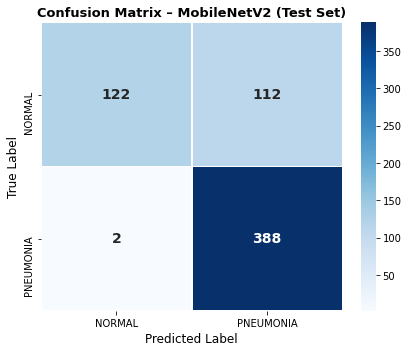


Sensitivity (Recall PNEUMONIA) : 99.49%
Specificity (Recall NORMAL)    : 52.14%


In [ ]:
print('=' * 55)
print('CLASSIFICATION REPORT')
print('=' * 55)
print(classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES, digits=4
))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

print(f'True  Negative (TN) – NORMAL đúng       : {tn}')
print(f'False Positive (FP) – NORMAL → PNEUMONIA: {fp}')
print(f'False Negative (FN) – PNEUMONIA → NORMAL: {fn}')
print(f'True  Positive (TP) – PNEUMONIA đúng    : {tp}')

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax, annot_kws={'size': 14, 'weight': 'bold'}
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix – MobileNetV2 (Test Set)', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

sensitivity = tp / (tp + fn) * 100
specificity = tn / (tn + fp) * 100
print(f'\nSensitivity (Recall PNEUMONIA) : {sensitivity:.2f}%')
print(f'Specificity (Recall NORMAL)    : {specificity:.2f}%')

## Tạo DataFrame tổng hợp lỗi

In [ ]:
df = pd.DataFrame({
    'path'        : all_paths,
    'true_label'  : all_labels,
    'pred_label'  : all_preds,
    'prob_pneumonia': all_probs,
})

df['true_name'] = df['true_label'].map({0: 'NORMAL', 1: 'PNEUMONIA'})
df['pred_name'] = df['pred_label'].map({0: 'NORMAL', 1: 'PNEUMONIA'})
df['correct']   = df['true_label'] == df['pred_label']

# Phân loại lỗi
df['error_type'] = 'Correct'
df.loc[(df['true_label'] == 0) & (df['pred_label'] == 1), 'error_type'] = 'False Positive'
df.loc[(df['true_label'] == 1) & (df['pred_label'] == 0), 'error_type'] = 'False Negative'

# Tạo confidence: xác suất của nhãn được predict
df['confidence'] = np.where(
    df['pred_label'] == 1,
    df['prob_pneumonia'],
    1 - df['prob_pneumonia']
)

error_df = df[~df['correct']].copy()
fp_df    = df[df['error_type'] == 'False Positive'].copy()
fn_df    = df[df['error_type'] == 'False Negative'].copy()

print(f'Tổng mẫu        : {len(df)}')
print(f'Dự đoán đúng    : {df["correct"].sum()} ({df["correct"].mean()*100:.2f}%)')
print(f'Dự đoán sai     : {(~df["correct"]).sum()} ({(~df["correct"]).mean()*100:.2f}%)')
print(f'  False Positive: {len(fp_df)}  (NORMAL bị phán là PNEUMONIA)')
print(f'  False Negative: {len(fn_df)}  (PNEUMONIA bị phán là NORMAL)')

df.head(5)

Tổng mẫu        : 624
Dự đoán đúng    : 510 (81.73%)
Dự đoán sai     : 114 (18.27%)
  False Positive: 112  (NORMAL bị phán là PNEUMONIA)
  False Negative: 2  (PNEUMONIA bị phán là NORMAL)


,path,true_label,pred_label,prob_pneumonia,true_name,pred_name,correct,error_type,confidence
0,/kaggle/input/chest-xray-pneumonia/chest_xray/...,0,1,0.579174,NORMAL,PNEUMONIA,False,False Positive,0.579174
1,/kaggle/input/chest-xray-pneumonia/chest_xray/...,0,1,0.998981,NORMAL,PNEUMONIA,False,False Positive,0.998981
2,/kaggle/input/chest-xray-pneumonia/chest_xray/...,0,0,0.000432,NORMAL,NORMAL,True,Correct,0.999568
3,/kaggle/input/chest-xray-pneumonia/chest_xray/...,0,1,0.999999,NORMAL,PNEUMONIA,False,False Positive,0.999999
4,/kaggle/input/chest-xray-pneumonia/chest_xray/...,0,0,0.000171,NORMAL,NORMAL,True,Correct,0.999829


## Phân phối Confidence Score

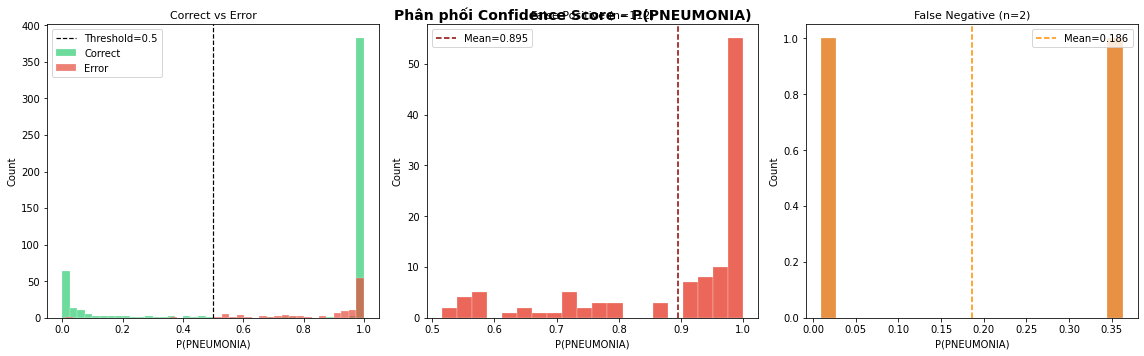

─── Confidence trung bình theo nhóm ───
Correct             : mean=0.9782  std=0.0739  min=0.5112  max=1.0000
False Positive      : mean=0.8949  std=0.1480  min=0.5153  max=1.0000
False Negative      : mean=0.8140  std=0.2498  min=0.6373  max=0.9906


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Phân phối Confidence Score – P(PNEUMONIA)', fontsize=14, weight='bold')

colors = {'Correct': '#2ecc71', 'False Positive': '#e74c3c', 'False Negative': '#e67e22'}

# (1) Correct vs Error
ax = axes[0]
ax.hist(df[df['correct']]['prob_pneumonia'],   bins=40, alpha=0.7,
        color='#2ecc71', label='Correct', edgecolor='white', linewidth=0.3)
ax.hist(df[~df['correct']]['prob_pneumonia'],  bins=40, alpha=0.7,
        color='#e74c3c', label='Error',   edgecolor='white', linewidth=0.3)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='Threshold=0.5')
ax.set_title('Correct vs Error', fontsize=11)
ax.set_xlabel('P(PNEUMONIA)')
ax.set_ylabel('Count')
ax.legend()

# (2) False Positive
ax = axes[1]
if len(fp_df) > 0:
    ax.hist(fp_df['prob_pneumonia'], bins=20, color='#e74c3c',
            alpha=0.85, edgecolor='white', linewidth=0.3)
    ax.axvline(fp_df['prob_pneumonia'].mean(), color='darkred',
               linestyle='--', linewidth=1.5,
               label=f'Mean={fp_df["prob_pneumonia"].mean():.3f}')
ax.set_title(f'False Positive (n={len(fp_df)})', fontsize=11)
ax.set_xlabel('P(PNEUMONIA)')
ax.set_ylabel('Count')
ax.legend()

# (3) False Negative
ax = axes[2]
if len(fn_df) > 0:
    ax.hist(fn_df['prob_pneumonia'], bins=20, color='#e67e22',
            alpha=0.85, edgecolor='white', linewidth=0.3)
    ax.axvline(fn_df['prob_pneumonia'].mean(), color='darkorange',
               linestyle='--', linewidth=1.5,
               label=f'Mean={fn_df["prob_pneumonia"].mean():.3f}')
ax.set_title(f'False Negative (n={len(fn_df)})', fontsize=11)
ax.set_xlabel('P(PNEUMONIA)')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.show()

# Thống kê confidence
print('─── Confidence trung bình theo nhóm ───')
for etype in ['Correct', 'False Positive', 'False Negative']:
    subset = df[df['error_type'] == etype]['confidence']
    if len(subset) > 0:
        print(f'{etype:20s}: mean={subset.mean():.4f}  '
              f'std={subset.std():.4f}  '
              f'min={subset.min():.4f}  '
              f'max={subset.max():.4f}')

## Visualize ảnh False Positive (NORMAL → PNEUMONIA) và False Negative (PNEUMONIA → NORMAL)

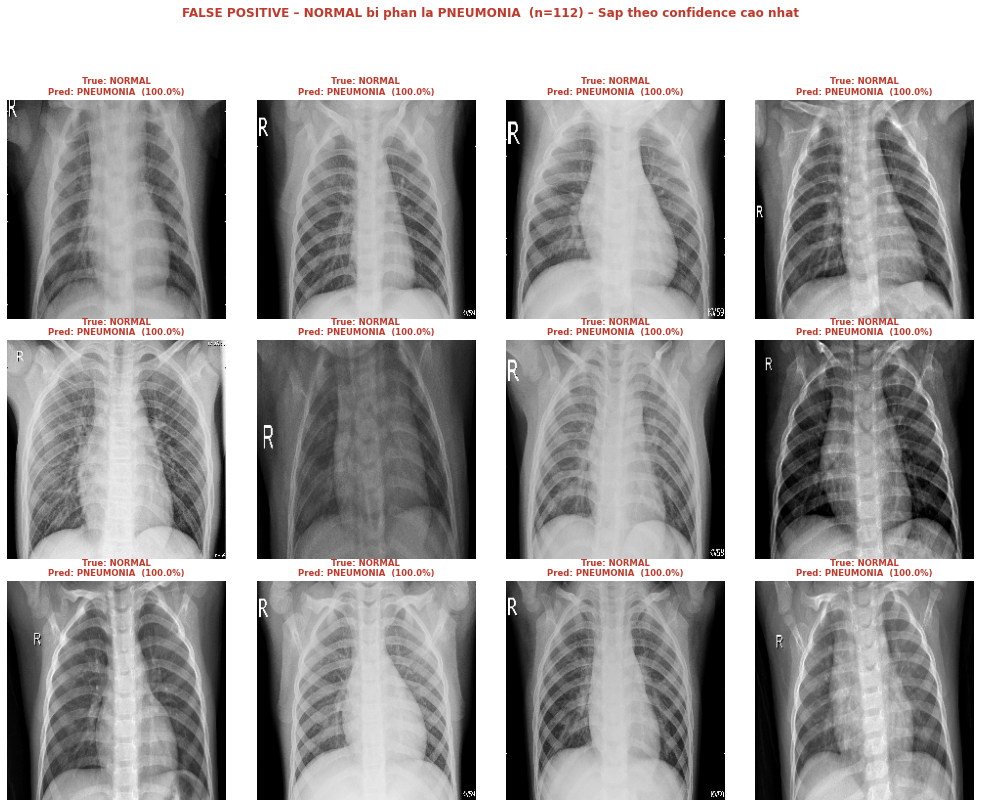

In [ ]:
def show_error_grid(error_subset, title, color, n_show=12, cols=4):
    if len(error_subset) == 0:
        print(f'Khong co loi loai: {title}')
        return

    subset = error_subset.nlargest(n_show, 'confidence')
    n_show = min(n_show, len(subset))
    rows   = (n_show + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.8))
    fig.suptitle(f'{title}  (n={len(error_subset)}) – Sap theo confidence cao nhat',
                 fontsize=12, weight='bold', color=color)
    axes = np.array(axes).flatten()

    for i, (_, row) in enumerate(subset.iterrows()):
        img = Image.open(row['path']).convert('RGB').resize((224, 224))
        axes[i].imshow(img)
        conf_pct = row['confidence'] * 100
        axes[i].set_title(
            f"True: {row['true_name']}\nPred: {row['pred_name']}  ({conf_pct:.1f}%)",
            fontsize=8.5, color=color, weight='bold'
        )
        axes[i].axis('off')
        for spine in axes[i].spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(color)
            spine.set_linewidth(2)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()


# FALSE POSITIVE: NORMAL nhung model doan PNEUMONIA
show_error_grid(fp_df,
                title='FALSE POSITIVE – NORMAL bi phan la PNEUMONIA',
                color='#c0392b', n_show=12, cols=4)

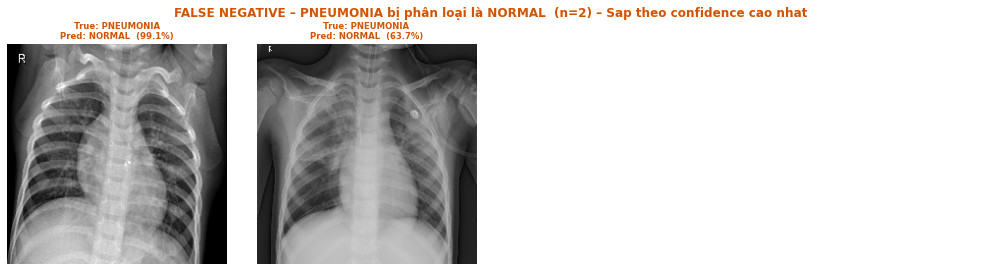

In [ ]:
# False Negative: PNEUMONIA nhưng model đoán NORMAL (nguy hiểm hơn – bỏ sót bệnh)
show_error_grid(
    fn_df,
    title='FALSE NEGATIVE – PNEUMONIA bị phân loại là NORMAL',
    color='#d35400',
    n_show=12, cols=4
)

Target layer: Conv2d (inside features[-1])
GRAD-CAM: FALSE POSITIVE
Model nhin vao vung nao khi phan NORMAL thanh PNEUMONIA?


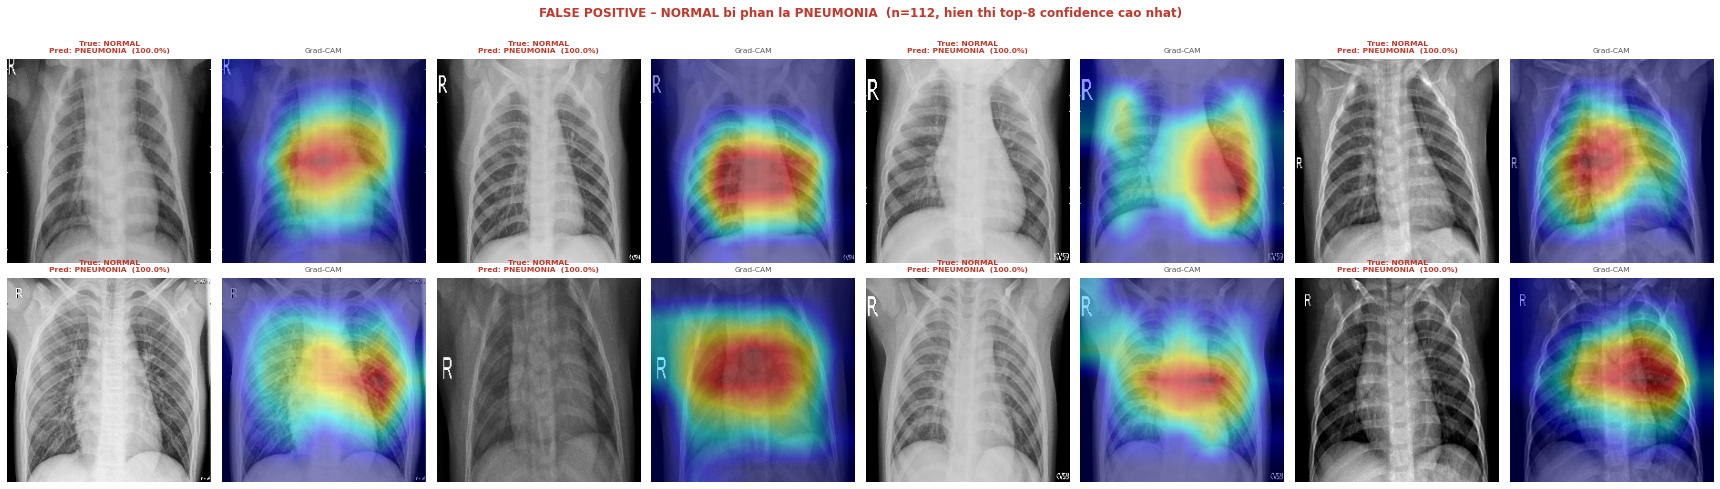

GRAD-CAM: FALSE NEGATIVE
Model nhin vao vung nao khi bo sot PNEUMONIA?


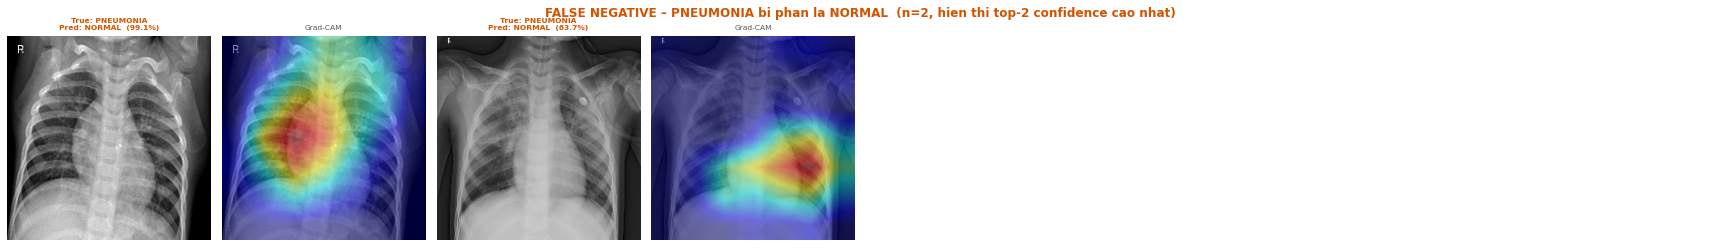

SO SANH GRAD-CAM: Correct PNEUMONIA vs False Negative
Model focus vao dau khi dung vs khi sai?


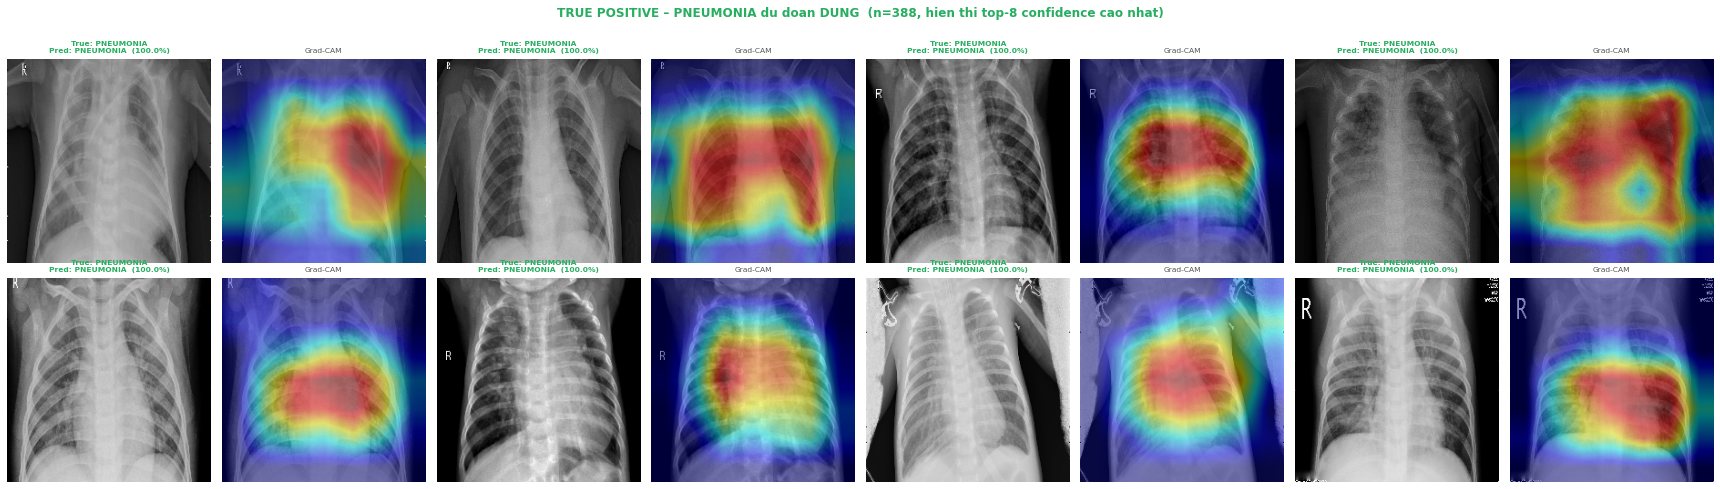

In [ ]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
import torch
import torch.nn.functional as F
from torchvision import transforms


# ── 1. GradCAM class ──────────────────────────────────────────────────────────
class GradCAM:
    """
    Grad-CAM cho MobileNetV2.
    Target layer: model.features[-1]  (lop conv cuoi cung truoc GlobalAvgPool)
    """

    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        # register_full_backward_hook chi co tu PyTorch 1.8+
        # fallback sang register_backward_hook cho cac version cu
        try:
            self.target_layer.register_full_backward_hook(backward_hook)
        except AttributeError:
            self.target_layer.register_backward_hook(backward_hook)

    def generate(self, img_tensor, class_idx=None):
        """
        img_tensor : (1, 3, 224, 224)  – da normalize
        class_idx  : None = dung class co score cao nhat
        Returns    : heatmap (H, W) gia tri 0-1
        """
        self.model.eval()
        img_tensor = img_tensor.to(next(self.model.parameters()).device)
        img_tensor.requires_grad_(True)

        logits = self.model(img_tensor)           # (1, num_classes)
        probs  = F.softmax(logits, dim=1)

        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        # Backward
        self.model.zero_grad()
        score = logits[0, class_idx]
        score.backward()

        # Grad-CAM formula
        # gradients  : (1, C, H, W)
        # activations: (1, C, H, W)
        weights    = self.gradients.mean(dim=[2, 3], keepdim=True)   # (1, C, 1, 1)
        cam        = (weights * self.activations).sum(dim=1)          # (1, H, W)
        cam        = F.relu(cam).squeeze(0).cpu().numpy()             # (H, W)

        # Normalize 0-1
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)
        return cam, class_idx, probs[0, class_idx].item()


# ── 2. Ham overlay heatmap len anh goc ────────────────────────────────────────
def overlay_heatmap(original_img_rgb, cam, alpha=0.45, colormap=cv2.COLORMAP_JET):
    """
    original_img_rgb : np.array (H, W, 3) uint8
    cam              : np.array (h, w) float 0-1
    Returns          : np.array (H, W, 3) uint8
    """
    H, W = original_img_rgb.shape[:2]

    # Resize cam ve kich thuoc anh goc
    heatmap = cv2.resize(cam, (W, H))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, colormap)     # BGR
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) # -> RGB

    # Blend
    blended = (alpha * heatmap + (1 - alpha) * original_img_rgb).astype(np.uint8)
    return blended


# ── 3. Transform (khong augment, chi normalize) ────────────────────────────────
infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])


# ── 4. Khoi tao GradCAM voi lop cuoi cung cua MobileNetV2 ─────────────────────
# MobileNetV2: features[-1] la ConvBNReLU/ConvBNActivation block
# features[-1][0] la Conv2d thuc su ben trong block – cho gradient chinh xac hon
try:
    # Uu tien hook vao Conv2d ben trong block
    target_layer = model.features[-1][0]
    _ = type(target_layer).__name__
except (IndexError, TypeError):
    # Fallback: dung ca block neu khong index duoc
    target_layer = model.features[-1]

gradcam = GradCAM(model, target_layer=target_layer)
print(f"Target layer: {type(target_layer).__name__} (inside features[-1])")


# ── 5. Ham visualize GradCAM cho 1 nhom loi ───────────────────────────────────
def show_gradcam_errors(error_df_subset, title, border_color,
                        n_show=8, cols=4, target_class=None):
    """
    Hien thi anh goc + GradCAM overlay cho cac truong hop sai.

    error_df_subset : DataFrame (fp_df hoac fn_df)
    title           : tieu de
    border_color    : mau vien (hex string)
    n_show          : so luong anh hien thi
    cols            : so cot
    target_class    : 0=NORMAL, 1=PNEUMONIA, None=class model predict
    """
    if len(error_df_subset) == 0:
        print(f"Khong co loi nao trong nhom: {title}")
        return

    # Lay n_show anh co confidence cao nhat (model tu tin sai nhat)
    subset = error_df_subset.nlargest(n_show, 'confidence')
    n      = len(subset)
    rows   = (n + cols - 1) // cols

    # Moi anh co 2 cot: goc + gradcam => tong cols * 2
    fig, axes = plt.subplots(rows, cols * 2,
                              figsize=(cols * 2 * 3.0, rows * 3.5))
    fig.suptitle(f"{title}  (n={len(error_df_subset)}, hien thi top-{n} confidence cao nhat)",
                 fontsize=12, weight='bold', color=border_color)

    axes = np.array(axes).reshape(rows, cols * 2)

    model.eval()
    for i, (_, row) in enumerate(subset.iterrows()):
        r      = i // cols
        c_base = (i % cols) * 2   # cot anh goc
        c_cam  = c_base + 1       # cot gradcam

        # --- Load anh ---
        pil_img  = Image.open(row['path']).convert('RGB').resize((224, 224))
        np_img   = np.array(pil_img)

        # --- GradCAM ---
        img_tensor = infer_transform(pil_img).unsqueeze(0)  # (1,3,224,224)
        cam, pred_cls, conf = gradcam.generate(img_tensor, class_idx=target_class)
        overlay = overlay_heatmap(np_img, cam, alpha=0.45)

        conf_pct   = row['confidence'] * 100
        title_left = (f"True: {row['true_name']}\n"
                      f"Pred: {row['pred_name']}  ({conf_pct:.1f}%)")

        # --- Plot anh goc ---
        ax = axes[r, c_base]
        ax.imshow(np_img)
        ax.set_title(title_left, fontsize=7.5, color=border_color, weight='bold')
        ax.axis('off')
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_edgecolor(border_color); sp.set_linewidth(1.5)

        # --- Plot GradCAM ---
        ax = axes[r, c_cam]
        ax.imshow(overlay)
        ax.set_title('Grad-CAM', fontsize=7.5, color='#555555')
        ax.axis('off')
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_edgecolor('#888888'); sp.set_linewidth(1.0)

    # Tat cac o thua
    total_slots = rows * cols
    for j in range(n, total_slots):
        r      = j // cols
        c_base = (j % cols) * 2
        axes[r, c_base].axis('off')
        axes[r, c_base + 1].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


# ── 6. Chay GradCAM cho FP (NORMAL bi phan la PNEUMONIA) ──────────────────────
print("=" * 60)
print("GRAD-CAM: FALSE POSITIVE")
print("Model nhin vao vung nao khi phan NORMAL thanh PNEUMONIA?")
print("=" * 60)

show_gradcam_errors(
    fp_df,
    title='FALSE POSITIVE – NORMAL bi phan la PNEUMONIA',
    border_color='#c0392b',
    n_show=8, cols=4,
    target_class=1    # xem model focus vao dau khi predict PNEUMONIA
)


# ── 7. Chay GradCAM cho FN (PNEUMONIA bi phan la NORMAL) ──────────────────────
print("=" * 60)
print("GRAD-CAM: FALSE NEGATIVE")
print("Model nhin vao vung nao khi bo sot PNEUMONIA?")
print("=" * 60)

show_gradcam_errors(
    fn_df,
    title='FALSE NEGATIVE – PNEUMONIA bi phan la NORMAL',
    border_color='#d35400',
    n_show=8, cols=4,
    target_class=0    # xem model focus vao dau khi predict NORMAL (sai)
)


# ── 8. So sanh: model nhin vao dau o anh DUNG vs SAI ─────────────────────────
print("=" * 60)
print("SO SANH GRAD-CAM: Correct PNEUMONIA vs False Negative")
print("Model focus vao dau khi dung vs khi sai?")
print("=" * 60)

# Lay 4 anh dung (TP) va 4 anh sai (FN) de so sanh
tp_df = df[(df['true_label'] == 1) & (df['pred_label'] == 1)].copy()

show_gradcam_errors(
    tp_df,
    title='TRUE POSITIVE – PNEUMONIA du doan DUNG',
    border_color='#27ae60',
    n_show=8, cols=4,
    target_class=1
)


Dang trich xuat embedding tu toan bo test set...
(Co the mat 1-2 phut)
Embedding shape : (624, 1280)
So mau NORMAL    : 234
So mau PNEUMONIA : 390

Dang tinh PCA...
  PCA explained variance: PC1=35.4%, PC2=8.8%
Dang tinh t-SNE (co the mat 2-5 phut)...
Dang tinh UMAP...
Done!



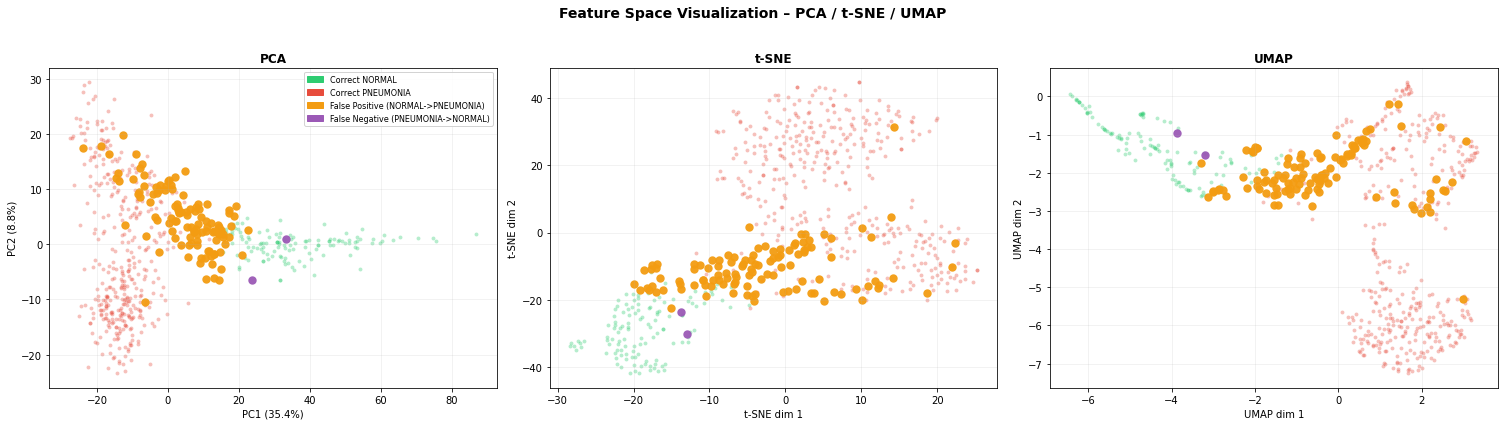


--- Phan tich vi tri trong khong gian PCA ---

Overlap score trung binh theo nhom (cao = gan ranh gioi, de bi sai):
  Correct NORMAL                : mean=0.2157  std=0.0943  n=122
  Correct PNEUMONIA             : mean=0.2533  std=0.0843  n=388
  False Positive                : mean=0.3305  std=0.1075  n=112
  False Negative                : mean=0.2045  std=0.0080  n=2


In [ ]:


import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

# Cai umap-learn neu chua co (Kaggle co the chua co san)
try:
    import umap
    HAS_UMAP = True
except ImportError:
    subprocess.run(['pip', 'install', 'umap-learn', '-q'])
    try:
        import umap
        HAS_UMAP = True
    except ImportError:
        HAS_UMAP = False
        print("Khong cai duoc umap-learn, bo qua UMAP.")

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


# ── 1. Trich xuat embedding 1280-d tu MobileNetV2 ────────────────────────────
# MobileNetV2: features -> (adaptive_avg_pool inline) -> flatten -> classifier
# Torchvision cu khong co model.avgpool attribute -> hook vao model.features
# va tu pool de lay vector 1280-d

print("Dang trich xuat embedding tu toan bo test set...")
print("(Co the mat 1-2 phut)")

embeddings_list = []
labels_list     = []
paths_list      = []

hook_output = {}

def features_hook(module, input, output):
    # output cua model.features: (B, 1280, H, W)
    # H, W = 7x7 voi input 224x224
    # Tu apply global avg pool -> (B, 1280)
    pooled = torch.nn.functional.adaptive_avg_pool2d(output, (1, 1))
    hook_output['feat'] = pooled.detach().flatten(1).cpu()

# Hook vao model.features (tuong thich moi torchvision version)
hook_handle = model.features.register_forward_hook(features_hook)

model.eval()
with torch.no_grad():
    for imgs, labels, paths in test_loader:
        imgs = imgs.to(DEVICE)
        _    = model(imgs)                              # forward pass -> hook chay
        embeddings_list.append(hook_output['feat'])     # (B, 1280)
        labels_list.extend(labels.numpy())
        paths_list.extend(paths)

hook_handle.remove()   # giai phong hook

embeddings = torch.cat(embeddings_list, dim=0).numpy()   # (N, 1280)
labels_arr = np.array(labels_list)

print(f"Embedding shape : {embeddings.shape}")
print(f"So mau NORMAL    : {(labels_arr == 0).sum()}")
print(f"So mau PNEUMONIA : {(labels_arr == 1).sum()}")


# ── 2. Tao nhan mau cho 4 nhom ────────────────────────────────────────────────
# Correct NORMAL    -> xanh la
# Correct PNEUMONIA -> do
# False Positive    -> cam (NORMAL bi phan la PNEUMONIA)
# False Negative    -> tim (PNEUMONIA bi phan la NORMAL)

# Tao dict path -> error_type
path_to_etype = dict(zip(df['path'], df['error_type']))

point_types = []
for p in paths_list:
    point_types.append(path_to_etype.get(p, 'Correct'))

point_types = np.array(point_types)

# Lay pred_label theo path
path_to_pred = dict(zip(df['path'], df['pred_label']))
preds_arr    = np.array([path_to_pred.get(p, -1) for p in paths_list])

COLOR_MAP = {
    'Correct NORMAL'   : '#2ecc71',   # xanh la
    'Correct PNEUMONIA': '#e74c3c',   # do
    'False Positive'   : '#f39c12',   # cam
    'False Negative'   : '#9b59b6',   # tim
}

def get_color(true_lbl, pred_lbl, etype):
    if etype == 'False Positive':
        return COLOR_MAP['False Positive']
    if etype == 'False Negative':
        return COLOR_MAP['False Negative']
    if true_lbl == 0:
        return COLOR_MAP['Correct NORMAL']
    return COLOR_MAP['Correct PNEUMONIA']

colors = np.array([
    get_color(t, p, e)
    for t, p, e in zip(labels_arr, preds_arr, point_types)
])

LEGEND_PATCHES = [
    mpatches.Patch(color=COLOR_MAP['Correct NORMAL'],    label='Correct NORMAL'),
    mpatches.Patch(color=COLOR_MAP['Correct PNEUMONIA'], label='Correct PNEUMONIA'),
    mpatches.Patch(color=COLOR_MAP['False Positive'],    label='False Positive (NORMAL->PNEUMONIA)'),
    mpatches.Patch(color=COLOR_MAP['False Negative'],    label='False Negative (PNEUMONIA->NORMAL)'),
]

# Size: loi to hon de de nhan ra
sizes = np.where(np.isin(point_types, ['False Positive', 'False Negative']), 80, 20)
alpha = np.where(np.isin(point_types, ['False Positive', 'False Negative']), 0.95, 0.35)


# ── 3. Chuan hoa truoc khi giam chieu ─────────────────────────────────────────
scaler     = StandardScaler()
emb_scaled = scaler.fit_transform(embeddings)


# ── 4. Tinh PCA / t-SNE / UMAP ───────────────────────────────────────────────
print("\nDang tinh PCA...")
pca     = PCA(n_components=2, random_state=42)
emb_pca = pca.fit_transform(emb_scaled)
var_exp = pca.explained_variance_ratio_
print(f"  PCA explained variance: PC1={var_exp[0]*100:.1f}%, PC2={var_exp[1]*100:.1f}%")

print("Dang tinh t-SNE (co the mat 2-5 phut)...")
pca50    = PCA(n_components=min(50, emb_scaled.shape[1]), random_state=42)
emb_50   = pca50.fit_transform(emb_scaled)
tsne     = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, verbose=0)
emb_tsne = tsne.fit_transform(emb_50)

emb_umap = None
if HAS_UMAP:
    print("Dang tinh UMAP...")
    reducer  = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                         random_state=42, verbose=False)
    emb_umap = reducer.fit_transform(emb_scaled)
else:
    print("Bo qua UMAP.")

print("Done!\n")


# ── 5. Ve 3 bieu do ngang hang ────────────────────────────────────────────────
datasets   = [emb_pca, emb_tsne] + ([emb_umap] if emb_umap is not None else [])
xlabels    = [f'PC1 ({var_exp[0]*100:.1f}%)', 't-SNE dim 1', 'UMAP dim 1']
ylabels    = [f'PC2 ({var_exp[1]*100:.1f}%)', 't-SNE dim 2', 'UMAP dim 2']
titlesplot = ['PCA', 't-SNE', 'UMAP']
n_plots    = len(datasets)

fig, axes = plt.subplots(1, n_plots, figsize=(n_plots * 7, 6))
fig.suptitle('Feature Space Visualization – PCA / t-SNE / UMAP',
             fontsize=14, weight='bold')

if n_plots == 1:
    axes = [axes]

ORDER = ['Correct NORMAL', 'Correct PNEUMONIA', 'False Positive', 'False Negative']

for ax, emb_2d, t, xl, yl in zip(axes, datasets, titlesplot, xlabels, ylabels):
    for etype in ORDER:
        if etype in ['Correct NORMAL', 'Correct PNEUMONIA']:
            mask = (point_types == 'Correct') & (
                (labels_arr == 0) if etype == 'Correct NORMAL' else (labels_arr == 1)
            )
        else:
            mask = (point_types == etype)
        if mask.sum() == 0:
            continue
        s   = 70 if etype in ['False Positive', 'False Negative'] else 15
        alp = 0.95 if etype in ['False Positive', 'False Negative'] else 0.35
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                   c=COLOR_MAP[etype], s=s, alpha=alp, linewidths=0)
    ax.set_title(t, fontsize=12, weight='bold')
    ax.set_xlabel(xl, fontsize=10)
    ax.set_ylabel(yl, fontsize=10)
    ax.grid(alpha=0.2)

axes[0].legend(handles=LEGEND_PATCHES, fontsize=8, framealpha=0.85)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()


# ── 8. Phan tich khoang cach den ranh gioi cluster ────────────────────────────
print("\n--- Phan tich vi tri trong khong gian PCA ---")

# Tinh centroid cua NORMAL va PNEUMONIA trong PCA space
normal_center    = emb_pca[labels_arr == 0].mean(axis=0)
pneumonia_center = emb_pca[labels_arr == 1].mean(axis=0)

# Khoang cach tu moi diem den 2 centroid
dist_to_normal    = np.linalg.norm(emb_pca - normal_center,    axis=1)
dist_to_pneumonia = np.linalg.norm(emb_pca - pneumonia_center, axis=1)

# "Overlap score" = khoang cach den centroid lop minh / khoang cach den centroid lop kia
# Gan 1 = nam chinh xac tren ranh gioi
overlap_score = np.minimum(dist_to_normal, dist_to_pneumonia) / \
               (dist_to_normal + dist_to_pneumonia + 1e-8)

df_feat = pd.DataFrame({
    'path'         : paths_list,
    'true_label'   : labels_arr,
    'pca_x'        : emb_pca[:, 0],
    'pca_y'        : emb_pca[:, 1],
    'overlap_score': overlap_score,
    'error_type'   : point_types,
})

print("\nOverlap score trung binh theo nhom (cao = gan ranh gioi, de bi sai):")
for etype in ['Correct NORMAL', 'Correct PNEUMONIA', 'False Positive', 'False Negative']:
    if etype in ['Correct NORMAL', 'Correct PNEUMONIA']:
        mask = (df_feat['error_type'] == 'Correct') & (
            (df_feat['true_label'] == 0) if etype == 'Correct NORMAL'
            else (df_feat['true_label'] == 1)
        )
    else:
        mask = df_feat['error_type'] == etype
    if mask.sum() == 0:
        continue
    scores = df_feat[mask]['overlap_score']
    print(f"  {etype:30s}: mean={scores.mean():.4f}  "
          f"std={scores.std():.4f}  n={mask.sum()}")

https://link.springer.com/chapter/10.1007/978-3-032-05461-6_31

Nghiên cứu paper này

## ROC Curve & AUC

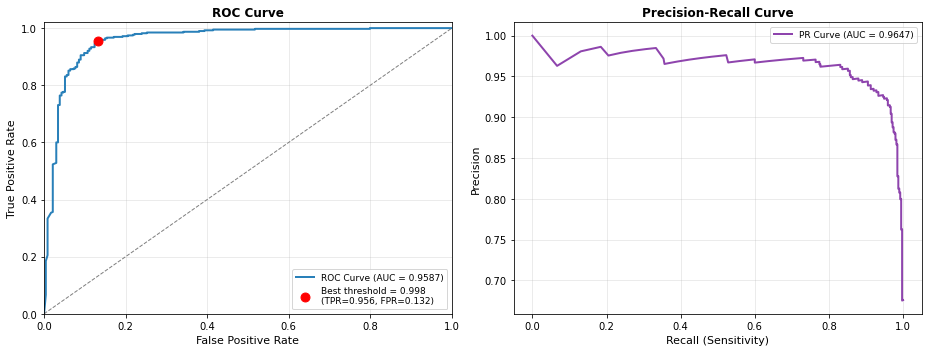

AUC-ROC : 0.9587
AUC-PR  : 0.9647
Youden optimal threshold: 0.9977


In [ ]:
fpr, tpr, thresholds_roc = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

# Youden's J statistic – ngưỡng tối ưu
youden_idx   = np.argmax(tpr - fpr)
best_thresh  = thresholds_roc[youden_idx]
best_tpr     = tpr[youden_idx]
best_fpr     = fpr[youden_idx]

# Precision-Recall
precision, recall, thresholds_pr = precision_recall_curve(all_labels, all_probs)
pr_auc = auc(recall, precision)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
ax = axes[0]
ax.plot(fpr, tpr, color='#2980b9', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
ax.scatter(best_fpr, best_tpr, marker='o', color='red', s=80, zorder=5,
           label=f'Best threshold = {best_thresh:.3f}\n(TPR={best_tpr:.3f}, FPR={best_fpr:.3f})')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve', fontsize=12, weight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

# Precision-Recall
ax = axes[1]
ax.plot(recall, precision, color='#8e44ad', lw=2, label=f'PR Curve (AUC = {pr_auc:.4f})')
ax.set_xlabel('Recall (Sensitivity)', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curve', fontsize=12, weight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'AUC-ROC : {roc_auc:.4f}')
print(f'AUC-PR  : {pr_auc:.4f}')
print(f'Youden optimal threshold: {best_thresh:.4f}')

## Phân tích theo ngưỡng (Threshold Analysis)

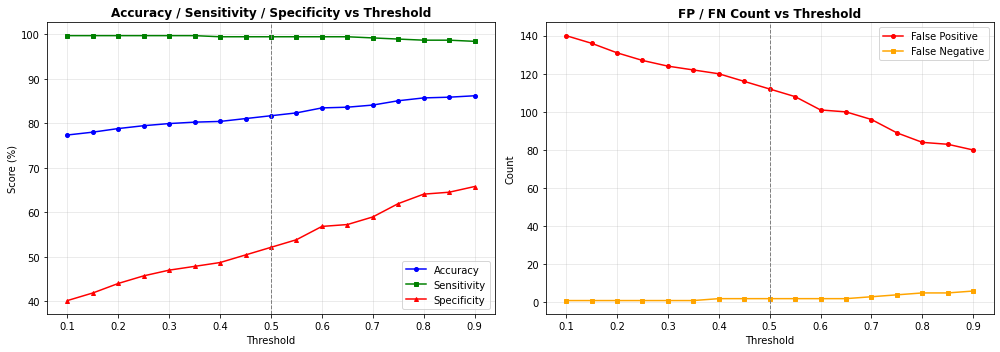


Bảng chi tiết:


,accuracy,sensitivity,specificity,f1_score,fp,fn
threshold,,,,,,
0.10,77.40,99.74,40.17,0.8466,140,1
0.15,78.04,99.74,41.88,0.8503,136,1
0.20,78.85,99.74,44.02,0.8549,131,1
0.25,79.49,99.74,45.73,0.8587,127,1
0.30,79.97,99.74,47.01,0.8616,124,1
0.35,80.29,99.74,47.86,0.8635,122,1
0.40,80.45,99.49,48.72,0.8641,120,2
0.45,81.09,99.49,50.43,0.8680,116,2
0.50,81.73,99.49,52.14,0.8719,112,2


In [ ]:
thresholds  = np.arange(0.1, 0.95, 0.05)
records     = []

for t in thresholds:
    preds_t = (all_probs >= t).astype(int)
    cm_t    = confusion_matrix(all_labels, preds_t, labels=[0, 1])
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    acc_t   = (preds_t == all_labels).mean() * 100
    sens_t  = tp_t / (tp_t + fn_t + 1e-9) * 100
    spec_t  = tn_t / (tn_t + fp_t + 1e-9) * 100
    f1_t    = 2 * tp_t / (2 * tp_t + fp_t + fn_t + 1e-9)
    records.append({
        'threshold'  : round(t, 2),
        'accuracy'   : round(acc_t, 2),
        'sensitivity': round(sens_t, 2),
        'specificity': round(spec_t, 2),
        'f1_score'   : round(f1_t, 4),
        'fp'         : fp_t,
        'fn'         : fn_t,
    })

thresh_df = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(thresh_df['threshold'], thresh_df['accuracy'],    'b-o', ms=4, label='Accuracy')
ax.plot(thresh_df['threshold'], thresh_df['sensitivity'], 'g-s', ms=4, label='Sensitivity')
ax.plot(thresh_df['threshold'], thresh_df['specificity'], 'r-^', ms=4, label='Specificity')
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Threshold')
ax.set_ylabel('Score (%)')
ax.set_title('Accuracy / Sensitivity / Specificity vs Threshold', weight='bold')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(thresh_df['threshold'], thresh_df['fp'], 'r-o', ms=4, label='False Positive')
ax.plot(thresh_df['threshold'], thresh_df['fn'], 'orange', marker='s', ms=4, label='False Negative')
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Threshold')
ax.set_ylabel('Count')
ax.set_title('FP / FN Count vs Threshold', weight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\nBảng chi tiết:')
display(thresh_df.set_index('threshold'))

## Confidence Calibration (Reliability Diagram)

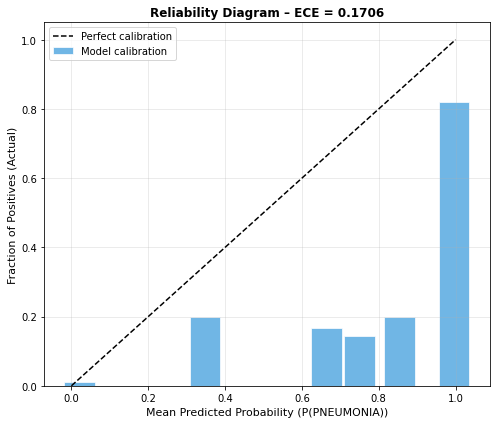

Expected Calibration Error (ECE): 0.1706


In [ ]:
# Chia xác suất thành 10 bin, so sánh mean confidence với accuracy thực tế
n_bins  = 10
bins    = np.linspace(0, 1, n_bins + 1)
bin_acc   = []
bin_conf  = []
bin_count = []

for i in range(n_bins):
    mask = (all_probs >= bins[i]) & (all_probs < bins[i + 1])
    if mask.sum() == 0:
        continue
    bin_acc.append(all_labels[mask].mean())           # fraction of true PNEUMONIA
    bin_conf.append(all_probs[mask].mean())            # mean predicted prob
    bin_count.append(mask.sum())

bin_acc   = np.array(bin_acc)
bin_conf  = np.array(bin_conf)
bin_count = np.array(bin_count)

ece = np.sum(bin_count * np.abs(bin_acc - bin_conf)) / len(all_labels)

fig, ax = plt.subplots(figsize=(7, 6))
ax.bar(bin_conf, bin_acc, width=0.08, alpha=0.7, color='#3498db',
       label='Model calibration', edgecolor='white')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability (P(PNEUMONIA))', fontsize=11)
ax.set_ylabel('Fraction of Positives (Actual)', fontsize=11)
ax.set_title(f'Reliability Diagram – ECE = {ece:.4f}', fontsize=12, weight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Expected Calibration Error (ECE): {ece:.4f}')


Mô hình đang overconfident (Mô hình có xu hướng đưa ra các dự đoán với xác suất rất cao ngay cả trong những trường hợp phân loại sai, đặc biệt là nhóm False Positive. Điều này cho thấy mô hình học được các đặc trưng mạnh của lớp PNEUMONIA nhưng đồng thời đánh giá quá mức độ chắc chắn của các dự đoán đó)

Phân tích đặc điểm ảnh lỗi (Kích thước, Aspect Ratio)

Dang doc metadata anh...


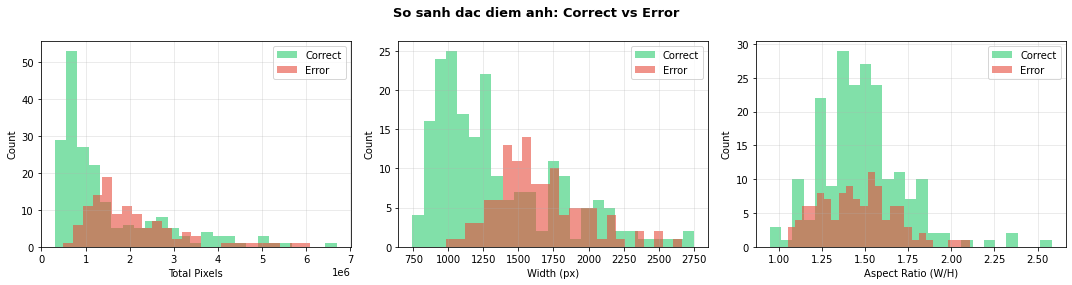

In [ ]:
def get_image_stats(path):
    try:
        img = Image.open(path)
        w, h = img.size
        return w, h, w * h, w / h
    except Exception:
        return None, None, None, None

print('Dang doc metadata anh...')

SAMPLE = 200
correct_sample = df[df['correct']].sample(min(SAMPLE, df['correct'].sum()), random_state=42)
error_sample   = error_df.sample(min(SAMPLE, len(error_df)), random_state=42)

def add_img_stats(sub_df):
    stats = sub_df['path'].apply(lambda p: pd.Series(
        get_image_stats(p), index=['width', 'height', 'pixels', 'aspect_ratio']
    ))
    return pd.concat([sub_df.reset_index(drop=True), stats], axis=1)

correct_s = add_img_stats(correct_sample)
error_s   = add_img_stats(error_sample)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('So sanh dac diem anh: Correct vs Error', fontsize=13, weight='bold')

for ax, col, xlabel in zip(
    axes,
    ['pixels', 'width', 'aspect_ratio'],
    ['Total Pixels', 'Width (px)', 'Aspect Ratio (W/H)']
):
    ax.hist(correct_s[col].dropna(), bins=25, alpha=0.6, color='#2ecc71', label='Correct')
    ax.hist(error_s[col].dropna(),   bins=25, alpha=0.6, color='#e74c3c', label='Error')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

Phân tích các đặc trưng hình học của ảnh cho thấy các mẫu dự đoán sai có xu hướng sở hữu kích thước và tỷ lệ khung hình lớn hơn so với các mẫu dự đoán đúng. Tuy nhiên, sự chồng lấn đáng kể giữa hai phân bố cho thấy các yếu tố này chỉ đóng vai trò phụ và không phải nguyên nhân chính dẫn đến lỗi phân loại. So với các đặc trưng hình học của ảnh, kết quả PCA, t-SNE và UMAP cho thấy sự khác biệt trong không gian đặc trưng học được bởi mô hình là yếu tố giải thích lỗi dự đoán thuyết phục hơn.

## Top ảnh model TỰ TIN NHẤT khi sai

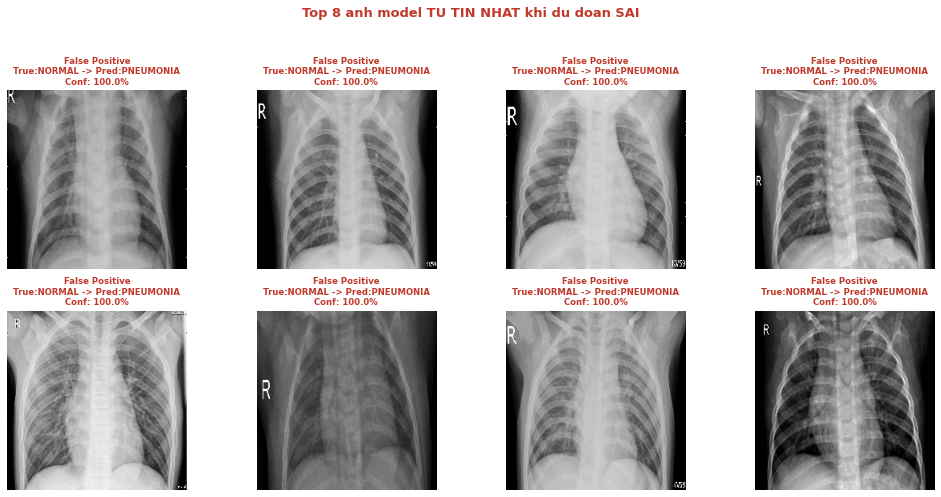

In [ ]:
TOP_N = 8
cols  = 4

fig, axes = plt.subplots(2, cols, figsize=(cols * 3.5, 7))
fig.suptitle(f'Top {TOP_N} anh model TU TIN NHAT khi du doan SAI',
             fontsize=13, weight='bold', color='#c0392b')

top_errors = error_df.nlargest(TOP_N, 'confidence')

for i, (_, row) in enumerate(top_errors.iterrows()):
    r, c = divmod(i, cols)
    ax   = axes[r][c]
    img  = Image.open(row['path']).convert('RGB').resize((224, 224))
    ax.imshow(img)
    color = '#c0392b' if row['error_type'] == 'False Positive' else '#d35400'
    ax.set_title(
        f"{row['error_type']}\nTrue:{row['true_name']} -> Pred:{row['pred_name']}\n"
        f"Conf: {row['confidence']*100:.1f}%",
        fontsize=8.5, color=color, weight='bold'
    )
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()